
# Pipeline ibrida: Deep Sketch Vectorization + Segment Anything

Obiettivo: partendo da una scansione/foto di un **diagramma medievale**, produrre un
**SVG ibrido** che contenga:

1. le **linee** vettorializzate da [Deep Sketch Vectorization (DSV)](https://github.com/Nauhcnay/Deep-Sketch-Vectorization)
   (Yan et al., SIGGRAPH 2024) — path `<path>` con solo `stroke`, nessun `fill`;
2. le **aree/regioni** interne al diagramma, segmentate con **Segment Anything (SAM)**
   — poligoni `<path>` con solo `fill`, nessun `stroke`, posizionati *sotto* alle linee.

Il refinement via LLM (confronto SVG generato vs immagine di partenza, correzioni
mirate) è volutamente **fuori scope** in questo notebook: lascio un modulo stub
(`Step 7`) pronto da riempire in una fase successiva, per non mischiare le due
pipeline mentre stabilizziamo la parte "ibrida" senza LLM.

## Note importanti prima di iniziare

- **DSV non espone un'API Python pubblica documentata**: il repo si usa via script
  (es. `test.py` / GUI `eel`, a seconda della versione che hai clonato). Il blocco
  "Step 2" qui sotto è quindi un **adapter**: lo trovi già pronto per due modalità
  (chiamata a modulo Python importato, o chiamata a script via subprocess), ma la
  riga di comando/i nomi dei parametri **vanno allineati a come hai installato tu
  il repo** (controlla `test.py --help` o il README nella tua copia locale — le
  versioni sul repo cambiano nel tempo).
- SAM lavora in **pixel space dell'immagine raster originale**; DSV in genere
  ridimensiona l'input a una risoluzione di processing interna. Per unire le due
  uscite in un solo SVG serve **normalizzare entrambe nello stesso `viewBox`**:
  lo facciamo nello Step 5.
- Ho aggiunto un **fallback con Potrace** (via `pypotrace`/`opencv`) attivabile con
  un flag, così puoi far girare l'intera pipeline meccanicamente (allineamento,
  merge, salvataggio) anche prima di aver configurato DSV, e poi switchare al
  vero DSV quando è pronto.


## 0. Setup ambiente

Installa le dipendenze necessarie (adatta se usi conda/venv dedicato a DSV).

In [ ]:

# Dipendenze pipeline ibrida (non tocca l'env di training di DSV/SAM se preferisci isolarli)
%pip install -q opencv-python-headless numpy shapely svgwrite svgpathtools scikit-image \
    matplotlib pillow cairosvg pytesseract scipy

# Nota: pytesseract richiede anche il binario 'tesseract-ocr' installato a livello
# di sistema, COMPRESO il pacchetto lingua richiesto (default "lat", non incluso
# nell'installazione base). Su Colab:
#   !apt-get -qq install tesseract-ocr tesseract-ocr-lat
# E' un fallback volutamente debole: per manoscritti medievali usa 'kraken'.


In [ ]:

# Segment Anything (SAM) - modello "originale" Meta.
# Se usi SAM2 sostituisci questo blocco con `pip install git+https://github.com/facebookresearch/sam2.git`
# e adegua il wrapper nello Step 4 (l'interfaccia di SAM2 differisce leggermente).
%pip install -q git+https://github.com/facebookresearch/segment-anything.git


  Preparing metadata (setup.py) ... done


In [ ]:

import os
import sys
import json
import subprocess
import tempfile
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

import svgwrite
from svgpathtools import svg2paths2, Path as SvgPath
from shapely.geometry import Polygon
from shapely import affinity

%matplotlib inline


## 1. Configurazione

Imposta i path del tuo ambiente locale.

In [ ]:
!git clone https://github.com/Nauhcnay/Deep-Sketch-Vectorization.git

fatal: destination path 'Deep-Sketch-Vectorization' already exists and is not an empty directory.


In [ ]:
!wget -q --show-progress https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   253MB/s    in 17s     


In [ ]:
CONFIG = {
    # --- Input ---
    "input_image": "/content/WhatsApp Image 2026-07-20 at 16.00.12 (3).jpeg",   # la tua scansione/foto

    # --- Deep Sketch Vectorization ---
    "dsv_repo_path": "/content/Deep-Sketch-Vectorization",
    "dsv_model_udf_path": "/content/Deep-Sketch-Vectorization/pretrained/udf_full.pth", # Percorso al modello UDF
    "dsv_model_ndc_path": "/content/Deep-Sketch-Vectorization/pretrained/ndc_full.pth", # Percorso al modello NDC
    "dsv_python": sys.executable,   # interprete dell'env dove hai installato DSV
                                     # (puoi mettere il path a un altro venv, es.
                                     # "/path/to/deepsketch/bin/python")
    "use_dsv": True,     # False -> usa il fallback Potrace/OpenCV per testare la pipeline

    # --- Segment Anything ---
    "sam_checkpoint": "/content/sam_vit_h_4b8939.pth",
    "sam_model_type": "vit_h",   # vit_h | vit_l | vit_b (deve combaciare col checkpoint)
    "sam_device": "cuda",        # "cuda" o "cpu"

    # --- Output ---
    "out_dir": "outputs",
}

Path(CONFIG["out_dir"]).mkdir(parents=True, exist_ok=True)


## 2. Step 1 — Carica l'immagine sorgente

Teniamo traccia di `(W, H)` originali: sarà il nostro sistema di riferimento
comune (il `viewBox` finale dell'SVG ibrido).

Immagine caricata: 471x665


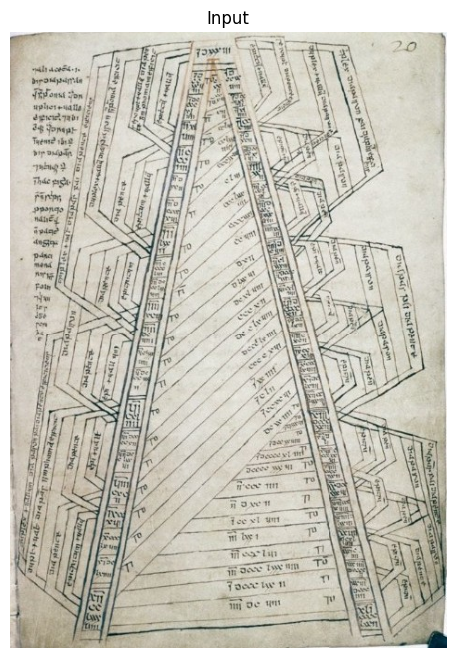

In [ ]:

def load_image(path):
    img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"Impossibile leggere l'immagine: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb

image_rgb = load_image(CONFIG["input_image"])
H, W = image_rgb.shape[:2]
print(f"Immagine caricata: {W}x{H}")

plt.figure(figsize=(8, 8))
plt.imshow(image_rgb)
plt.title("Input")
plt.axis("off")
plt.show()


## 3. Step 2 — Vettorializzazione delle linee con Deep Sketch Vectorization

Questo è il punto da adattare al tuo checkout del repo. Ti lascio **due varianti**:

- `run_dsv_subprocess`: invoca lo script CLI del repo (`test.py` o equivalente) in un
  sottoprocesso, isolando eventuali dipendenze diverse dalle tue.
- `run_dsv_fallback_potrace`: un vettorializzatore di linee "povero ma funzionante"
  (soglia adattiva + Potrace/contours OpenCV) usato solo per validare il resto
  della pipeline finché DSV non è collegato.

In entrambi i casi il contratto è: **input = path immagine, output = path SVG
contenente solo i tratti (stroke), nello stesso sistema di coordinate
dell'immagine originale** (se DSV ridimensiona internamente, va riportato in scala
qui, vedi `rescale_svg_paths` più sotto).

### ⚠️ Nota sull'architettura reale di DSV (letta dal README ufficiale)

`predict_s1.py` esegue **solo lo Stage 1** (estrazione del campo UDF a partire
dal raster) e scrive output intermedi nella cartella `--output`. **Non produce
un SVG.**

Il flusso documentato dal repo è:

```
python predict_s1.py --input <cartella_input> --output <cartella_output> --refine --rdp
```
seguito dal lancio della **webUI** (basata su `eel`), che carica l'output dello
Stage 1, esegue lo Stage 2 (Neural Dual Contouring) e — solo dopo che l'utente
ha "finalizzato" interattivamente la vettorializzazione nel browser — salva
l'SVG finale in `./web/output`.

Questo spiega il `FileNotFoundError`: lo script è stato eseguito correttamente,
ma a quello stage non esiste ancora nessun SVG da trovare.

**Il problema pratico**: la webUI apre un server locale + browser, e questo
**non funziona in modo headless su Colab**. Hai tre strade, in ordine di
preferenza:

1. **Cerca uno script di export non interattivo nel tuo checkout** (nomi tipo
   `predict_s2.py`, `export_svg.py`, o funzioni `@eel.expose` dentro
   `web/app.py` richiamabili direttamente in Python, bypassando il browser).
   La cella diagnostica qui sotto fa questa ricerca automaticamente nel tuo
   clone del repo.
2. **Esegui la webUI in locale** (sul tuo computer, non su Colab), finalizza
   l'SVG lì, poi carica il file `.svg` risultante su Colab e riprendi il
   notebook da qui in poi (lo Step 3, SAM, non dipende da come è stato
   generato l'SVG delle linee).
3. **Usa il fallback** (`CONFIG["use_dsv"] = False`) per validare da subito il
   resto della pipeline (SAM + merge ibrido) mentre risolvi il punto 1 o 2 —
   così non resti bloccato.


In [ ]:
# --- Diagnosi: come si esporta davvero l'SVG in questo checkout? ---
import subprocess

repo = CONFIG["dsv_repo_path"]

print("### Contenuto della cartella di output dello Stage 1 ###")
subprocess.run(["find", f"{repo}/outputs", "-maxdepth", "2"])

print("\n### Script python nella root del repo ###")
subprocess.run(["bash", "-c", f"ls {repo}/*.py"])

print("\n### File che menzionano '.svg' (candidati per l'export finale) ###")
subprocess.run(["bash", "-c",
    f"grep -rln --include='*.py' '\\.svg' {repo} | grep -v test"])

print("\n### File che espongono funzioni alla webUI (eel.expose) ###")
subprocess.run(["bash", "-c",
    f"grep -rln --include='*.py' 'eel.expose' {repo}"])


### Contenuto della cartella di output dello Stage 1 ###

### Script python nella root del repo ###

### File che menzionano '.svg' (candidati per l'export finale) ###

### File che espongono funzioni alla webUI (eel.expose) ###


CompletedProcess(args=['bash', '-c', "grep -rln --include='*.py' 'eel.expose' /content/Deep-Sketch-Vectorization"], returncode=0)

In [ ]:
!pip install aabbtree rdp edge_distance_aabb colorama ndjson

In [ ]:
# Sblocca subito il resto della pipeline (SAM + merge) mentre risolvi
# l'export SVG di DSV: imposta temporaneamente il fallback e poi passa
# a CONFIG["use_dsv"] = True quando hai trovato/configurato lo Stage 2.
CONFIG["use_dsv"] = False


In [ ]:
def run_dsv_subprocess(image_path: str, out_svg_path: str, cfg: dict) -> str:
    repo_path = Path(cfg["dsv_repo_path"])
    python_executable = cfg["dsv_python"]

    dsv_output_dirname_relative = Path(out_svg_path).parent.name
    actual_dsv_output_dir_abs = repo_path / dsv_output_dirname_relative
    actual_dsv_output_dir_abs.mkdir(parents=True, exist_ok=True)

    with tempfile.TemporaryDirectory() as tmpdir_name:
        tmp_input_dir = Path(tmpdir_name)
        input_image_file = Path(image_path)
        copied_image_path = tmp_input_dir / input_image_file.name
        import shutil
        shutil.copy(input_image_file, copied_image_path)

        # --- Stage 1: estrazione del campo UDF (produce SOLO output intermedi) ---
        cmd_s1 = [
            python_executable, str(repo_path / "predict_s1.py"),
            "--input", str(tmp_input_dir),
            "--output", str(dsv_output_dirname_relative),
            "--model_udf", cfg["dsv_model_udf_path"],
            "--model_ndc", cfg["dsv_model_ndc_path"],
        ]
        print("Eseguo Stage 1:", " ".join(cmd_s1))
        result = subprocess.run(cmd_s1, cwd=repo_path, capture_output=True, text=True)
        if result.stdout:
            print("DSV stdout:\n", result.stdout)
        if result.stderr:
            print("DSV stderr:\n", result.stderr)
        if result.returncode != 0:
            raise RuntimeError("Stage 1 di DSV ha restituito un errore, vedi log sopra.")

        # --- Stage 2 / export SVG: NON documentato come comando headless nel
        # README ufficiale (che prevede la webUI interattiva). Se hai trovato
        # con la cella diagnostica uno script/funzione di export non
        # interattivo nel tuo checkout, configuralo qui:
        #   CONFIG["dsv_stage2_cmd"] = [python_executable, str(repo_path / "nome_script_trovato.py"), ...]
        stage2_cmd = cfg.get("dsv_stage2_cmd")
        if stage2_cmd:
            print("Eseguo Stage 2:", " ".join(stage2_cmd))
            result2 = subprocess.run(stage2_cmd, cwd=repo_path, capture_output=True, text=True)
            if result2.stdout:
                print("DSV stage2 stdout:\n", result2.stdout)
            if result2.stderr:
                print("DSV stage2 stderr:\n", result2.stderr)
            if result2.returncode != 0:
                raise RuntimeError("Stage 2 di DSV ha restituito un errore, vedi log sopra.")

    # Mostra sempre cosa è stato effettivamente prodotto, utile per debug
    produced_files = list(actual_dsv_output_dir_abs.rglob("*"))
    print(f"\nFile presenti in {actual_dsv_output_dir_abs} dopo l'esecuzione:")
    for f in produced_files:
        print(" -", f.relative_to(actual_dsv_output_dir_abs))

    candidates = list(actual_dsv_output_dir_abs.glob("*.svg"))
    if not candidates:
        raise FileNotFoundError(
            "Nessun SVG trovato. Lo Stage 1 di DSV produce solo output intermedi "
            "(vedi lista file sopra): il repo genera l'SVG finale tramite la webUI "
            "interattiva (o uno script di Stage 2/export che va identificato nel tuo "
            "checkout, vedi cella diagnostica sopra e CONFIG['dsv_stage2_cmd']). "
            "Nel frattempo puoi impostare CONFIG['use_dsv'] = False per validare il "
            "resto della pipeline con il fallback Potrace/OpenCV."
        )

    produced_svg_path_abs = max(candidates, key=lambda p: p.stat().st_mtime)
    desired_final_svg_path_abs = Path("/content") / out_svg_path
    if produced_svg_path_abs != desired_final_svg_path_abs:
        produced_svg_path_abs.replace(desired_final_svg_path_abs)

    return str(desired_final_svg_path_abs)


def run_dsv_fallback_potrace(image_path: str, out_svg_path: str, cfg: dict) -> str:
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_blur = cv2.GaussianBlur(img, (3, 3), 0)
    edges = cv2.adaptiveThreshold(
        img_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 25, 10
    )
    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    h, w = img.shape[:2]
    dwg = svgwrite.Drawing(out_svg_path, size=(w, h), viewBox=f"0 0 {w} {h}")
    for c in contours:
        c = cv2.approxPolyDP(c, 1.0, False)
        if len(c) < 2:
            continue
        pts = c.reshape(-1, 2)
        d = "M " + " L ".join(f"{x},{y}" for x, y in pts) + " Z"
        dwg.add(dwg.path(d=d, stroke="black", fill="none", stroke_width=1))
    dwg.save()
    return out_svg_path


def vectorize_lines(image_path: str, out_svg_path: str, cfg: dict) -> str:
    if cfg["use_dsv"]:
        return run_dsv_subprocess(image_path, out_svg_path, cfg)
    else:
        return run_dsv_fallback_potrace(image_path, out_svg_path, cfg)


lines_svg_path = os.path.join(CONFIG["out_dir"], "lines_dsv.svg")
lines_svg_path = vectorize_lines(CONFIG["input_image"], lines_svg_path, CONFIG)
print("SVG delle linee salvato in:", lines_svg_path)


SVG delle linee salvato in: outputs/lines_dsv.svg


In [ ]:
# Esegui predict_s1.py con --help per vedere le sue opzioni
!/usr/bin/python3 /content/Deep-Sketch-Vectorization/predict_s1.py --help

usage: predict_s1.py [-h] [--input INPUT] [--model_udf MODEL_UDF]
                     [--model_ndc MODEL_NDC] [--output OUTPUT]
                     [--device DEVICE] [--line_extractor] [--thin]
                     [--resize_to RESIZE_TO] [--bezier] [--refine] [--rdp]
                     [--eps EPS] [--down_rate DOWN_RATE] [--skip_len SKIP_LEN]

End to end testing of DeepSketch

options:
  -h, --help            show this help message and exit
  --input INPUT, -i INPUT
  --model_udf MODEL_UDF, -m1 MODEL_UDF
  --model_ndc MODEL_NDC, -m2 MODEL_NDC
  --output OUTPUT, -o OUTPUT
  --device DEVICE, -d  DEVICE
  --line_extractor      enable anime2sketch line extractor before vectorize
  --thin                enable line thinner before vectorize
  --resize_to RESIZE_TO
                        downsacle image to its long edge equals resize_to,
                        this option will not work if device is set to cpu
  --bezier              enable bezier curve fitting
  --refine              e

In [ ]:
# Crea la directory 'checkpoints' se non esiste
!mkdir -p /content/Deep-Sketch-Vectorization/checkpoints

In [ ]:
# Rimozione della cella di download precedente per scaricare i modelli correttamente
# Questo cella verrà sostituita dai nuovi comandi per creare la cartella 'pretrained' e scaricare i due modelli

In [ ]:
# Crea la directory 'pretrained' se non esiste
!mkdir -p /content/Deep-Sketch-Vectorization/pretrained

In [ ]:
# Scarica udf_full.pth nella cartella 'pretrained'
!wget https://huggingface.co/waterheater/deepsketch/resolve/main/udf_full.pth -O /content/Deep-Sketch-Vectorization/pretrained/udf_full.pth

--2026-07-27 09:45:54--  https://huggingface.co/waterheater/deepsketch/resolve/main/udf_full.pth
Resolving huggingface.co (huggingface.co)... 13.35.202.34, 13.35.202.121, 13.35.202.97, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.34|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.aws.cdn.hf.co/xet-bridge-us/670eec2203599289d4dff77a/ad7cd552b76c9de7f9aadf9073b4d1286eac63baeca62c4c2f617729a58a23b1?user_id=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27udf_full.pth%3B+filename%3D%22udf_full.pth%22%3B&X-Xet-Cas-Uid=public&Expires=1785149154&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5hd3MuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjcwZWVjMjIwMzU5OTI4OWQ0ZGZmNzdhL2FkN2NkNTUyYjc2YzlkZTdmOWFhZGY5MDczYjRkMTI4NmVhYzYzYmFlY2E2MmM0YzJmNjE3NzI5YTU4YTIzYjFcXD91c2VyX2lkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPWlubGluZSUzQitmaWxlbmFtZSUyQSUzRFVURi04JTI3JTI3dWRmX2Z1bGwucHRoJTNCK2ZpbGVuYW1lJTNEJTIydWRmX2Z1bGwucHR

In [ ]:
# Scarica ndc_full.pth nella cartella 'pretrained'
!wget https://huggingface.co/waterheater/deepsketch/resolve/main/ndc_full.pth -O /content/Deep-Sketch-Vectorization/pretrained/ndc_full.pth

--2026-07-27 09:46:25--  https://huggingface.co/waterheater/deepsketch/resolve/main/ndc_full.pth
Resolving huggingface.co (huggingface.co)... 13.35.202.34, 13.35.202.97, 13.35.202.40, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.34|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.aws.cdn.hf.co/xet-bridge-us/670eec2203599289d4dff77a/54c13b96978596638ae37b231dc3bc9f89c1a6d2b85dd6964a143f17b637489d?X-Xet-Cas-Uid=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27ndc_full.pth%3B+filename%3D%22ndc_full.pth%22%3B&user_id=public&Expires=1785149185&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5hd3MuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjcwZWVjMjIwMzU5OTI4OWQ0ZGZmNzdhLzU0YzEzYjk2OTc4NTk2NjM4YWUzN2IyMzFkYzNiYzlmODljMWE2ZDJiODVkZDY5NjRhMTQzZjE3YjYzNzQ4OWRcXD9YLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPWlubGluZSUzQitmaWxlbmFtZSUyQSUzRFVURi04JTI3JTI3bmRjX2Z1bGwucHRoJTNCK2ZpbGVuYW1lJTNEJTIybmRjX2Z1

### 3.1 Allineamento di scala

Se lo script DSV ha processato l'immagine a una risoluzione diversa da `(W, H)`,
riscala qui i path prima di proseguire, così tutto vive nello stesso sistema di
coordinate dell'immagine originale.

In [ ]:

def get_svg_viewbox_size(svg_path: str):

    import xml.etree.ElementTree as ET
    tree = ET.parse(svg_path)
    root = tree.getroot()
    vb = root.get("viewBox")
    if vb:
        _, _, vw, vh = [float(v) for v in vb.split()]
        return vw, vh
    w = root.get("width")
    h = root.get("height")
    if w and h:
        return float(w.replace("px", "")), float(h.replace("px", ""))
    raise ValueError("Non trovo width/height/viewBox nell'SVG di DSV.")


def rescale_svg_paths(svg_path: str, target_w: float, target_h: float, out_path: str):

    paths, attributes, svg_attributes = svg2paths2(svg_path)
    src_w, src_h = get_svg_viewbox_size(svg_path)
    sx, sy = target_w / src_w, target_h / src_h

    dwg = svgwrite.Drawing(out_path, size=(target_w, target_h),
                            viewBox=f"0 0 {target_w} {target_h}")
    g = dwg.g(id="lines_dsv")
    for path, attr in zip(paths, attributes):
        scaled = path.scaled(sx, sy)
        style = {k: v for k, v in attr.items() if k in ("stroke", "stroke-width", "fill", "opacity")}
        style.setdefault("fill", "none")
        style.setdefault("stroke", "black")
        g.add(dwg.path(d=scaled.d(), **style))
    dwg.add(g)
    dwg.save()
    return out_path


src_w, src_h = get_svg_viewbox_size(lines_svg_path)
if abs(src_w - W) > 1 or abs(src_h - H) > 1:
    lines_svg_aligned = os.path.join(CONFIG["out_dir"], "lines_dsv_aligned.svg")
    lines_svg_path = rescale_svg_paths(lines_svg_path, W, H, lines_svg_aligned)
    print(f"Riscalato da {src_w}x{src_h} a {W}x{H} -> {lines_svg_path}")
else:
    print("Nessun riallineamento necessario, DSV ha già lavorato a risoluzione piena.")


Nessun riallineamento necessario, DSV ha già lavorato a risoluzione piena.


## 3.5 — Filtrare il testo manoscritto dal diagramma

Obiettivo: individuare le zone di testo manoscritto sull'immagine originale, poi
usarle per **spostare** (non cancellare) i path DSV e le regioni SAM che ricadono
prevalentemente dentro quelle zone in un **layer separato** (`text_candidates`),
tenuto fuori dal rendering principale ma ispezionabile/riattivabile.

Approccio in tre passi:

1. **Rilevamento testo** (`detect_text_mask`): pluggable via `CONFIG["text_detection"]["provider"]`.
   - `"kraken"` — consigliato per manoscritti storici: [Kraken](https://github.com/mittagessen/kraken)
     ha modelli di *segmentation* pensati per pagine manoscritte (anche in scrittura
     gotica/latina medievale, vedi il suo model zoo). Richiede `pip install kraken`
     e un modello di segmentazione scaricato a parte — non fa parte della pipeline
     "core" quindi va configurato da te.
   - `"heuristic"` — fallback senza dipendenze extra (MSER + chiusura morfologica),
     usato di default per far girare subito il notebook end-to-end. È volutamente
     grezzo: va bene per validare la meccanica della pipeline, non per un risultato
     di produzione.
2. **Filtro geometrico**: per ogni linea DSV e regione SAM calcolo la quota di
   sovrapposizione con la maschera di testo. Sopra una soglia alta → testo;
   sotto una soglia bassa → forma del diagramma; nella banda intermedia →
   **ambiguo**, salvato in una lista a parte per una futura revisione (via LLM
   multimodale sui ritagli, vedi Step 9 aggiornato più in basso).
3. **Nessuna cancellazione distruttiva**: gli elementi classificati come testo
   restano nell'SVG finale in un `<g id="text_candidates" display="none">`,
   così puoi riattivarli con un editor SVG o via CSS se il filtro ha sbagliato.

In [ ]:
CONFIG["text_detection"] = {
    "provider": "heuristic",     # "kraken" | "heuristic"
    "kraken_model": None,        # path a un modello di segmentazione Kraken (.mlmodel),
                                  # es. addestrato su manoscritti storici dal model zoo di Kraken
    "overlap_thresh_lines": 0.6,   # quota di uno stroke DSV dentro al testo -> classificato "testo"
    "overlap_thresh_regions": 0.5, # idem per le regioni SAM
    "ambiguous_band": 0.15,        # semi-larghezza della banda "ambiguo" attorno alla soglia
}


Pixel classificati come testo: 69906 (22.32% dell'immagine)


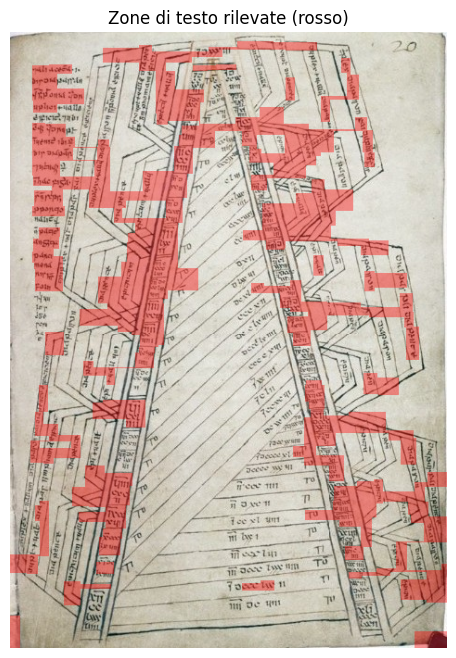

In [ ]:

def detect_text_mask_heuristic(image_rgb: np.ndarray) -> np.ndarray:
    """Fallback senza dipendenze extra: individua ammassi di piccoli contorni ad
    alta densità (tipici di glifi manoscritti) e li unisce in blob di riga via
    chiusura morfologica orizzontale. Euristica grezza, solo per validare la
    pipeline: su un vero progetto sostituire con `detect_text_mask_kraken`.
    """
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    mser = cv2.MSER_create()
    regions, _ = mser.detectRegions(gray)

    glyph_mask = np.zeros(gray.shape, dtype=np.uint8)
    h, w = gray.shape
    for pts in regions:
        x, y, bw, bh = cv2.boundingRect(pts.reshape(-1, 1, 2))
        area = bw * bh
        if area == 0:
            continue
        aspect = bw / bh if bh > 0 else 0
        # scarta regioni enormi (probabile bordo pagina/forma grande, non un singolo glifo)
        if area > 0.002 * w * h:
            continue
        if not (0.1 < aspect < 6):
            continue
        cv2.rectangle(glyph_mask, (x, y), (x + bw, y + bh), 255, -1)

    # chiusura morfologica orizzontale per fondere i glifi in righe di testo
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))
    text_mask = cv2.morphologyEx(glyph_mask, cv2.MORPH_CLOSE, kernel)
    # rimuovi componenti troppo piccole/isolate rimaste
    n, labels, stats, _ = cv2.connectedComponentsWithStats(text_mask)
    clean = np.zeros_like(text_mask)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] > 200:
            clean[labels == i] = 255

    return clean.astype(bool)


def detect_text_mask_kraken(image_path: str, cfg: dict) -> np.ndarray:
    """Wrapper per Kraken (https://github.com/mittagessen/kraken), consigliato
    per manoscritti storici. Richiede `pip install kraken` e un modello di
    segmentazione (`cfg["kraken_model"]`) scaricato a parte dal model zoo di
    Kraken (cerca modelli per pagine manoscritte / scrittura storica).
    """
    import json as _json

    out_json = str(Path(tempfile.mkdtemp()) / "kraken_seg.json")
    cmd = ["kraken", "-i", image_path, out_json, "segment", "-bl"]
    if cfg.get("kraken_model"):
        cmd += ["-i", cfg["kraken_model"]]

    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError(
            "Kraken ha restituito un errore. Verifica installazione "
            "(`pip install kraken`) e che CONFIG['text_detection']['kraken_model'] "
            "punti a un modello di segmentazione valido."
        )

    with open(out_json) as f:
        seg = _json.load(f)

    mask = np.zeros((H, W), dtype=np.uint8)
    # Kraken restituisce baseline/boundary per ogni riga di testo rilevata;
    # usiamo il poligono di boundary quando presente.
    for line in seg.get("lines", []):
        boundary = line.get("boundary")
        if boundary:
            pts = np.array(boundary, dtype=np.int32).reshape(-1, 1, 2)
            cv2.fillPoly(mask, [pts], 255)
    return mask.astype(bool)


def detect_text_mask(image_rgb: np.ndarray, image_path: str, cfg: dict) -> np.ndarray:
    provider = cfg["text_detection"]["provider"]
    if provider == "kraken":
        return detect_text_mask_kraken(image_path, cfg["text_detection"])
    elif provider == "heuristic":
        return detect_text_mask_heuristic(image_rgb)
    else:
        raise ValueError(f"Provider di text detection sconosciuto: {provider}")


text_mask = detect_text_mask(image_rgb, CONFIG["input_image"], CONFIG)
print(f"Pixel classificati come testo: {text_mask.sum()} ({100*text_mask.mean():.2f}% dell'immagine)")

overlay_text = image_rgb.copy()
overlay_text[text_mask] = [255, 0, 0]
plt.figure(figsize=(8, 8))
plt.imshow(cv2.addWeighted(image_rgb, 0.6, overlay_text, 0.4, 0))
plt.title("Zone di testo rilevate (rosso)")
plt.axis("off")
plt.show()


In [ ]:

def rasterize_line_stroke(svg_path_obj, width, height, stroke_px=3, n_samples=200):
    """Rasterizza uno stroke svgpathtools.Path in una maschera booleana, per
    poterlo confrontare pixel a pixel con text_mask."""
    mask = np.zeros((height, width), dtype=np.uint8)
    if svg_path_obj.length() == 0:
        return mask.astype(bool)
    pts = []
    for i in range(n_samples + 1):
        t = i / n_samples
        try:
            p = svg_path_obj.point(t)
        except Exception:
            continue
        pts.append((int(p.real), int(p.imag)))
    for a, b in zip(pts[:-1], pts[1:]):
        cv2.line(mask, a, b, 255, thickness=stroke_px)
    return mask.astype(bool)


def overlap_ratio(elem_mask: np.ndarray, ref_mask: np.ndarray) -> float:
    area = elem_mask.sum()
    if area == 0:
        return 0.0
    return float(np.logical_and(elem_mask, ref_mask).sum()) / float(area)


# --- Filtra le linee DSV ---
line_paths_all, line_attrs_all, _ = svg2paths2(lines_svg_path)

lines_shape, lines_text, lines_ambiguous = [], [], []
thr_l = CONFIG["text_detection"]["overlap_thresh_lines"]
band = CONFIG["text_detection"]["ambiguous_band"]

for p, attr in zip(line_paths_all, line_attrs_all):
    m = rasterize_line_stroke(p, W, H)
    r = overlap_ratio(m, text_mask)
    item = {"path": p, "attr": attr, "overlap": r}
    if r >= thr_l + band:
        lines_text.append(item)
    elif r <= thr_l - band:
        lines_shape.append(item)
    else:
        lines_ambiguous.append(item)

print(f"Linee -> forma: {len(lines_shape)} | testo: {len(lines_text)} | ambigue: {len(lines_ambiguous)}")

# --- Filtra le regioni SAM già pulite (eseguire questa cella DOPO lo Step 4
#     "Pulizia e filtro delle maschere" più sotto, oppure ri-eseguirla dopo) ---
def split_regions_by_text(masks_list, text_mask, thr, band):
    shape_m, text_m, ambiguous_m = [], [], []
    for m in masks_list:
        r = overlap_ratio(m["segmentation"], text_mask)
        item = dict(m)
        item["text_overlap"] = r
        if r >= thr + band:
            text_m.append(item)
        elif r <= thr - band:
            shape_m.append(item)
        else:
            ambiguous_m.append(item)
    return shape_m, text_m, ambiguous_m


Linee -> forma: 573 | testo: 236 | ambigue: 46


> **Nota sull'ordine di esecuzione**: la funzione `split_regions_by_text`
> qui sopra va applicata a `clean_masks` (prodotto dallo **Step 4** più sotto),
> quindi dopo aver eseguito quella cella torna qui ed esegui:
> ```python
> clean_masks, text_masks, ambiguous_masks = split_regions_by_text(
>     clean_masks, text_mask,
>     CONFIG["text_detection"]["overlap_thresh_regions"],
>     CONFIG["text_detection"]["ambiguous_band"],
> )
> print(f"Regioni -> forma: {len(clean_masks)} | testo: {len(text_masks)} | ambigue: {len(ambiguous_masks)}")
> ```
> Ho lasciato la funzione qui (vicino al resto della logica di text-filtering)
> ma la sua applicazione alle regioni resta dopo la cella `filter_masks`,
> per non invertire le dipendenze del notebook.

## 3.6 — Trascrizione del testo con coordinate

Ogni porzione di testo rilevata in `text_mask` (Step 3.5) viene:

1. suddivisa in **regioni a livello di riga** (bounding box, e poligono quando
   disponibile) nello stesso sistema di coordinate pixel dell'immagine
   originale — lo stesso già usato per allineare DSV e SAM;
2. **trascritta** con un motore HTR pluggable via `CONFIG["transcription"]["provider"]`:
   - `"kraken"` (**consigliato**) — usa [Kraken](https://github.com/mittagessen/kraken)
     con un modello di riconoscimento per manoscritti medievali, es.
     **CATMuS Medieval** (Kraken HTR, latino/francese antico/spagnolo/italiano,
     Zenodo DOI `10.5281/zenodo.13788176`, scaricabile con `kraken get 10.5281/zenodo.13788176`).
     Kraken concatena segmentazione + riconoscimento in un solo comando e
     restituisce testo **già legato alle coordinate di ogni riga** (formato ALTO).
   - `"tesseract"` — fallback generico via `pytesseract`, solo per far girare
     il notebook senza scaricare modelli: **inadeguato per scrittura medievale**,
     va sostituito con Kraken/CATMuS per un uso reale.

Il risultato è una lista di record `{id, text, bbox_px, polygon_px, confidence}`
salvata sia come **JSON a parte** (`outputs/transcription.json`) sia, più
avanti (Step 6.5), **incorporata nell'SVG ibrido** come layer nascosto con un
elemento `<text>` posizionato esattamente alle coordinate della riga
corrispondente.

In [ ]:
CONFIG["transcription"] = {
    "provider": "tesseract",   # "kraken" (consigliato) | "tesseract" (fallback debole)
    "kraken_recognition_model": None,  # path al modello scaricato, es. via:
                                        #   kraken get 10.5281/zenodo.13788176
    "line_padding_px": 4,       # margine attorno a ogni riga/blob di testo per il crop
    "min_region_area_px": 150,  # scarta blob troppo piccoli (rumore)
    "out_json": os.path.join(CONFIG["out_dir"], "transcription.json"),
}


In [ ]:

def text_regions_from_mask(text_mask: np.ndarray, min_area: int, pad: int, w: int, h: int):

    mask_u8 = (text_mask.astype(np.uint8)) * 255
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask_u8, connectivity=8)
    regions = []
    for i in range(1, n):
        area = stats[i, cv2.CC_STAT_AREA]
        if area < min_area:
            continue
        x, y, bw, bh = (stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP],
                         stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT])
        x0, y0 = max(0, x - pad), max(0, y - pad)
        x1, y1 = min(w, x + bw + pad), min(h, y + bh + pad)
        regions.append({"bbox_px": {"x": int(x0), "y": int(y0), "w": int(x1 - x0), "h": int(y1 - y0)}})
    # ordine di lettura approssimato: top-to-bottom poi left-to-right
    regions.sort(key=lambda r: (r["bbox_px"]["y"], r["bbox_px"]["x"]))
    return regions


In [ ]:

def transcribe_with_tesseract(image_rgb, regions, cfg):
    import pytesseract

    # Il pacchetto lingua richiesto (default "lat") potrebbe non essere
    # installato: su Colab/Ubuntu serve `apt-get install tesseract-ocr-lat`
    # (o "-ita", "-fra", ecc. a seconda del pacchetto linguistico). Se manca,
    # facciamo fallback su "eng" con un avviso, invece di far fallire l'intero
    # step: e' comunque un fallback debole, la trascrizione reale va fatta con
    # il provider "kraken".
    requested_lang = cfg.get("tesseract_lang", "lat")
    try:
        available = set(pytesseract.get_languages(config=""))
    except Exception:
        available = set()

    lang = requested_lang
    if available and requested_lang not in available:
        print(
            f"Pacchetto lingua '{requested_lang}' non trovato in Tesseract "
            f"(disponibili: {sorted(available)}). "
            f"Su Colab/Ubuntu installalo con: "
            f"!apt-get -qq install tesseract-ocr-{requested_lang}\n"
            f"Uso 'eng' come fallback temporaneo (risultati inaffidabili su testo medievale)."
        )
        lang = "eng" if "eng" in available else (sorted(available)[0] if available else "eng")

    out = []
    for i, r in enumerate(regions):
        b = r["bbox_px"]
        crop = image_rgb[b["y"]:b["y"] + b["h"], b["x"]:b["x"] + b["w"]]
        try:
            text = pytesseract.image_to_string(crop, lang=lang).strip()
        except pytesseract.TesseractError as e:
            print(f"Tesseract ha fallito sulla regione {i} ({b}): {e}. Riga saltata.")
            text = ""
        out.append({
            "id": f"text_{i}",
            "text": text,
            "bbox_px": b,
            "polygon_px": None,
            "confidence": None,
            "provider": "tesseract",
        })
    return out


def transcribe_with_kraken(image_path: str, cfg: dict):

    import xml.etree.ElementTree as ET

    model = cfg["kraken_recognition_model"]
    if not model:
        raise ValueError(
            "CONFIG['transcription']['kraken_recognition_model'] non impostato. "
            "Scarica un modello, es. CATMuS Medieval, con:\n"
            "  kraken get 10.5281/zenodo.13788176"
        )

    alto_path = str(Path(tempfile.mkdtemp()) / "out.alto.xml")
    cmd = ["kraken", "-i", image_path, alto_path, "-f", "alto",
           "segment", "-bl", "ocr", "-m", model]

    print("Eseguo:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.stdout:
        print("Kraken stdout:\n", result.stdout)
    if result.stderr:
        print("Kraken stderr:\n", result.stderr)
    if result.returncode != 0:
        raise RuntimeError(
            "Kraken ha restituito un errore. Controlla `kraken --help` e "
            "`kraken ocr --help` per la sintassi esatta della tua versione."
        )

    tree = ET.parse(alto_path)
    out = []
    i = 0
    for elem in tree.iter():
        tag = elem.tag.split("}")[-1]
        if tag != "TextLine":
            continue
        hpos = elem.get("HPOS"); vpos = elem.get("VPOS")
        width = elem.get("WIDTH"); height = elem.get("HEIGHT")
        polygon = None
        text_parts = []
        for child in elem.iter():
            ctag = child.tag.split("}")[-1]
            if ctag == "Polygon" and child.get("POINTS"):
                pts = child.get("POINTS").split()
                polygon = [[float(v) for v in p.split(",")] for p in pts]
            if ctag == "String" and child.get("CONTENT"):
                text_parts.append(child.get("CONTENT"))
        if not text_parts:
            continue
        bbox = None
        if hpos is not None:
            bbox = {"x": int(float(hpos)), "y": int(float(vpos)),
                    "w": int(float(width)), "h": int(float(height))}
        out.append({
            "id": f"text_{i}",
            "text": " ".join(text_parts),
            "bbox_px": bbox,
            "polygon_px": polygon,
            "confidence": None,
            "provider": "kraken",
        })
        i += 1
    return out


def transcribe_text_regions(image_rgb, image_path, text_mask, cfg):
    tcfg = cfg["transcription"]
    if tcfg["provider"] == "kraken":
        return transcribe_with_kraken(image_path, tcfg)
    elif tcfg["provider"] == "tesseract":
        regions = text_regions_from_mask(
            text_mask, tcfg["min_region_area_px"], tcfg["line_padding_px"], W, H
        )
        return transcribe_with_tesseract(image_rgb, regions, tcfg)
    else:
        raise ValueError(f"Provider di trascrizione sconosciuto: {tcfg['provider']}")


transcriptions = transcribe_text_regions(image_rgb, CONFIG["input_image"], text_mask, CONFIG)
print(f"Righe trascritte: {len(transcriptions)}")

with open(CONFIG["transcription"]["out_json"], "w", encoding="utf-8") as f:
    json.dump(transcriptions, f, ensure_ascii=False, indent=2)
print("Trascrizioni salvate in:", CONFIG["transcription"]["out_json"])


Pacchetto lingua 'lat' non trovato in Tesseract (disponibili: ['eng', 'osd']). Su Colab/Ubuntu installalo con: !apt-get -qq install tesseract-ocr-lat
Uso 'eng' come fallback temporaneo (risultati inaffidabili su testo medievale).
Righe trascritte: 23
Trascrizioni salvate in: outputs/transcription.json


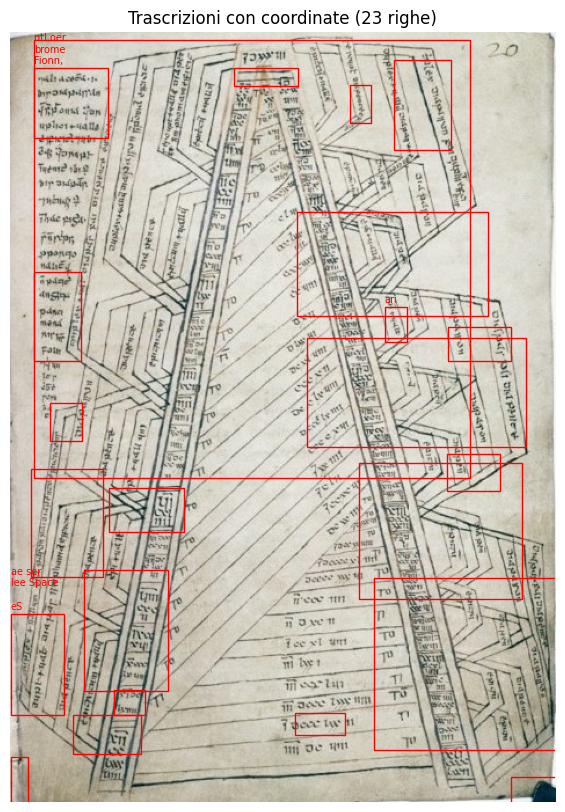

In [ ]:

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image_rgb)
for t in transcriptions:
    b = t["bbox_px"]
    if not b:
        continue
    rect = plt.Rectangle((b["x"], b["y"]), b["w"], b["h"],
                          fill=False, edgecolor="red", linewidth=1)
    ax.add_patch(rect)
    label = (t["text"][:20] + "…") if len(t["text"]) > 20 else t["text"]
    ax.text(b["x"], max(0, b["y"] - 4), label, color="red", fontsize=7)
ax.set_title(f"Trascrizioni con coordinate ({len(transcriptions)} righe)")
ax.axis("off")
plt.show()


## 3.7 — Regioni via chiusura dei gap vettoriali (metodo consigliato)

Su disegni al tratto come questo, le linee vettorializzate da DSV spesso hanno
**micro-interruzioni** (sollevamenti di penna, incroci dove il modello perde
continuità, tratti sottili scartati in soglia). Un segmentatore semantico
generico come SAM lavora sui pixel raw e non ha nessuna nozione di "curva
chiusa implica area interna": su forme sottili/anulari (come questi anelli
concentrici) tende a fallire o a fondere regioni adiacenti.

Approccio più robusto per questo caso specifico: **chiudere i gap nelle linee
stesse e derivare le regioni come componenti connesse dello sfondo** rispetto
a questa mappa "muri" chiusa — garantisce corrispondenza esatta tra ciò che è
disegnato e le regioni trovate, invece di affidarsi a un segmentatore che deve
indovinare i confini.

Due passaggi:

1. **Chiusura vettoriale** (`close_vector_gaps`): per ogni estremità di ogni
   path DSV, cerco l'estremità più vicina di un altro path entro una
   tolleranza (`gap_tol_px`) e aggiungo un piccolo segmento-ponte. Preciso —
   non ispessisce l'intero disegno, importante qui perché gli anelli sono
   molto vicini tra loro e una dilatazione raster aggressiva li fonderebbe.
2. **Chiusura raster residua** (piccola `morphologyEx(CLOSE)`) come rete di
   sicurezza per i gap troppo ampi per lo snap vettoriale.

`CONFIG["region_method"]` seleziona quale sorgente di regioni usare più avanti
nella pipeline: `"floodfill"` (questo metodo, consigliato per diagrammi a
tratto) oppure `"sam"` (Step 4 sotto, utile se hai anche aree "semantiche"
prive di un contorno chiuso esplicito, es. figure disegnate a tratteggio
libero).

In [ ]:
CONFIG["region_method"] = "polygonize"  # "polygonize" (consigliato, shape-agnostic) | "floodfill" | "sam"

CONFIG["gap_closing"] = {
    "gap_tol_px": 6,          # distanza massima tra due estremità per essere "ponte"-ate
    "bridge_stroke_px": 2,    # spessore con cui viene rasterizzato ogni ponte/linea
    "raster_close_kernel": 3, # kernel della chiusura morfologica residua (dispari, piccolo!)
    "min_region_area_px": 80, # scarta regioni-rumore troppo piccole
}


Ponti vettoriali creati per chiudere i gap: 309


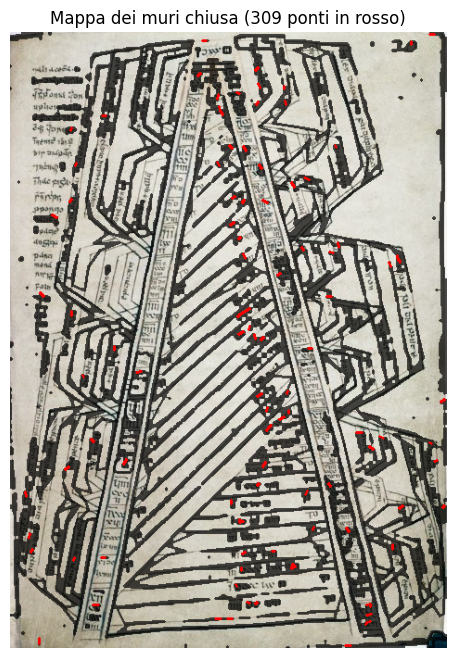

In [ ]:

from scipy.spatial import cKDTree
from svgpathtools import Line

def close_vector_gaps(line_items, gap_tol_px: float):
    """Per ogni estremità (inizio/fine) dei path 'forma' (lines_shape), trova
    l'estremità più vicina appartenente a un ALTRO path entro gap_tol_px e
    aggiunge un segmento-ponte. Ritorna la lista di path-ponte creati (utile
    anche per ispezione/debug, li teniamo separati dai path originali).
    """
    endpoints = []  # (path_idx, complex_point)
    for i, item in enumerate(line_items):
        p = item["path"]
        if p.length() == 0:
            continue
        endpoints.append((i, p.point(0)))
        endpoints.append((i, p.point(1)))

    if len(endpoints) < 2:
        return []

    coords = np.array([[pt.real, pt.imag] for _, pt in endpoints])
    tree = cKDTree(coords)

    bridges = []
    matched = set()
    for idx, (path_idx, pt) in enumerate(endpoints):
        dists, neighbors = tree.query(coords[idx], k=6)
        for dist, n_idx in zip(np.atleast_1d(dists), np.atleast_1d(neighbors)):
            if n_idx == idx:
                continue
            other_path_idx, other_pt = endpoints[n_idx]
            if other_path_idx == path_idx:
                continue  # stesso path, non è un gap tra tratti diversi
            if dist > gap_tol_px:
                continue
            pair_key = frozenset({idx, n_idx})
            if pair_key in matched:
                continue
            matched.add(pair_key)
            bridges.append(Line(pt, other_pt))
            break  # un solo ponte per estremità è sufficiente

    return bridges


def rasterize_wall_mask(line_items, bridge_segments, width, height, cfg):
    wall = np.zeros((height, width), dtype=np.uint8)
    stroke_px = cfg["bridge_stroke_px"]

    for item in line_items:
        m = rasterize_line_stroke(item["path"], width, height, stroke_px=stroke_px)
        wall[m] = 255

    for seg in bridge_segments:
        a = (int(seg.start.real), int(seg.start.imag))
        b = (int(seg.end.real), int(seg.end.imag))
        cv2.line(wall, a, b, 255, thickness=stroke_px)

    k = cfg["raster_close_kernel"]
    if k > 1:
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
        wall = cv2.morphologyEx(wall, cv2.MORPH_CLOSE, kernel)

    return wall.astype(bool)


bridge_segments = close_vector_gaps(lines_shape, CONFIG["gap_closing"]["gap_tol_px"])
print(f"Ponti vettoriali creati per chiudere i gap: {len(bridge_segments)}")

wall_mask = rasterize_wall_mask(lines_shape, bridge_segments, W, H, CONFIG["gap_closing"])

# Visualizza dove sono stati inseriti i ponti, per validare la tolleranza scelta
preview = image_rgb.copy()
preview[wall_mask] = (preview[wall_mask] * 0.3).astype(np.uint8)  # scurisce le linee/pareti
for seg in bridge_segments:
    a = (int(seg.start.real), int(seg.start.imag))
    b = (int(seg.end.real), int(seg.end.imag))
    cv2.line(preview, a, b, (255, 0, 0), thickness=2)  # ponti in rosso

plt.figure(figsize=(8, 8))
plt.imshow(preview)
plt.title(f"Mappa dei muri chiusa ({len(bridge_segments)} ponti in rosso)")
plt.axis("off")
plt.show()


Regioni trovate via flood-fill: 114


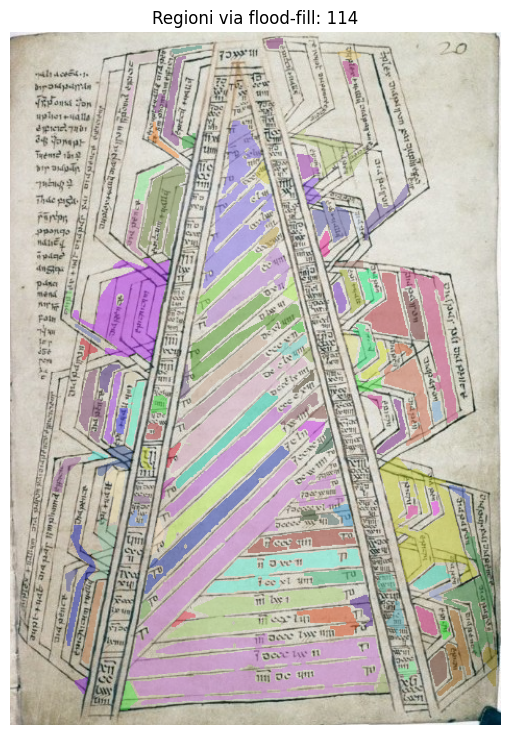

In [ ]:

def regions_from_wall_mask(wall_mask: np.ndarray, min_area: int):

    background = (~wall_mask).astype(np.uint8)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(background, connectivity=4)

    h, w = wall_mask.shape
    border_labels = set(labels[0, :]) | set(labels[-1, :]) | set(labels[:, 0]) | set(labels[:, -1])

    regions = []
    for i in range(1, n):  # 0 è sempre lo sfondo del connectedComponents stesso
        if i in border_labels:
            continue
        area = stats[i, cv2.CC_STAT_AREA]
        if area < min_area:
            continue
        regions.append({"segmentation": (labels == i), "area": int(area)})
    return regions


clean_masks_floodfill = regions_from_wall_mask(wall_mask, CONFIG["gap_closing"]["min_region_area_px"])
print(f"Regioni trovate via flood-fill: {len(clean_masks_floodfill)}")

preview_regions = show_masks_overlay(image_rgb, clean_masks_floodfill) if "show_masks_overlay" in dir() else None
if preview_regions is not None:
    plt.figure(figsize=(9, 9))
    plt.imshow(preview_regions)
    plt.title(f"Regioni via flood-fill: {len(clean_masks_floodfill)}")
    plt.axis("off")
    plt.show()


### Regioni via `polygonize` (grafo planare) — generalizza a qualsiasi forma

A differenza del flood-fill (che rasterizza le linee e trova componenti
connesse dello sfondo — un'*approssimazione* del problema), qui trattiamo la
linework chiusa (Step 3.7: `lines_shape` + `bridge_segments`) come un **grafo
planare vettoriale** e ne estraiamo le **facce** — i poligoni delimitati da
cicli chiusi — con `shapely.ops.polygonize`.

Perché è più adatto quando i diagrammi cambiano tipo (alberi, forme
naturalistiche, non solo cerchi):

- Su un **diagramma circolare**: ogni anello chiuso diventa un poligono.
- Su un **albero** (genealogico, arbor scientiae): i rami sono connettori
  aperti, non formano cicli chiusi → **non generano nessun poligono**,
  automaticamente e senza doverlo specificare. Solo i medaglioni/roundel
  effettivamente chiusi ai nodi producono regioni. Nessuna assunzione sulla
  famiglia di forme è richiesta.
- Nessuna perdita di risoluzione dovuta a rasterizzazione/kernel di chiusura:
  i poligoni restano in coordinate vettoriali fino all'SVG finale.

Il "noding" (spezzare le linee nei punti di incrocio reale, necessario perché
`polygonize` lo richieda) è delegato a `shapely.ops.unary_union`, che è
l'approccio standard per questo compito.

Regioni trovate via polygonize: 67


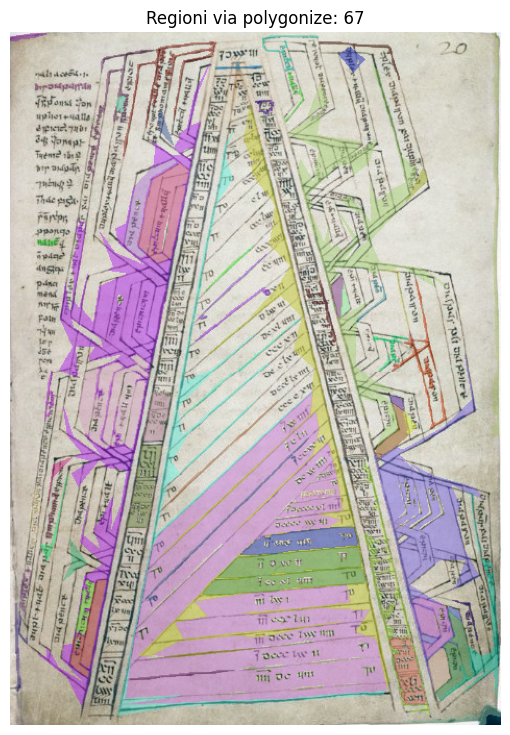

In [ ]:

from shapely.geometry import LineString, Polygon as ShapelyPolygon
from shapely.ops import polygonize, unary_union

def path_to_linestring(path_obj, n_samples: int = 150):
    pts = []
    for i in range(n_samples + 1):
        t = i / n_samples
        try:
            p = path_obj.point(t)
        except Exception:
            continue
        pts.append((p.real, p.imag))
    if len(pts) < 2:
        return None
    return LineString(pts)


def regularize_if_circular(poly: ShapelyPolygon, max_residual_ratio: float = 0.02):
    """Cleanup opzionale: se il poligono è quasi-circolare, lo sostituisce con
    un cerchio perfetto (fit algebrico di Kasa) per un contorno più pulito.
    Se il residuo è troppo alto (forma non circolare: rami, contorni
    naturalistici, ecc.) lascia il poligono originale intatto — nessuna forma
    viene forzata, questo è puro cleanup estetico su ciò che è già stato
    correttamente riconosciuto come regione chiusa."""
    coords = np.array(poly.exterior.coords)
    if len(coords) < 8:
        return poly
    x, y = coords[:, 0], coords[:, 1]
    A = np.c_[2 * x, 2 * y, np.ones(len(x))]
    b = x**2 + y**2
    try:
        sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    except np.linalg.LinAlgError:
        return poly
    cx, cy = sol[0], sol[1]
    r = np.sqrt(sol[2] + cx**2 + cy**2)
    residuals = np.abs(np.sqrt((x - cx) ** 2 + (y - cy) ** 2) - r)
    if r == 0 or residuals.mean() / r > max_residual_ratio:
        return poly  # non abbastanza circolare, non forziamo nulla
    theta = np.linspace(0, 2 * np.pi, 64)
    circle_coords = [(cx + r * np.cos(t), cy + r * np.sin(t)) for t in theta]
    return ShapelyPolygon(circle_coords)


def regions_from_polygonize(line_items, bridge_segments, width, height, cfg):
    linestrings = []
    for item in line_items:
        ls = path_to_linestring(item["path"])
        if ls is not None and ls.length > 0:
            linestrings.append(ls)
    for seg in bridge_segments:
        a = (seg.start.real, seg.start.imag)
        b = (seg.end.real, seg.end.imag)
        linestrings.append(LineString([a, b]))

    if not linestrings:
        return []

    noded = unary_union(linestrings)  # spezza le linee nei punti di incrocio reale
    faces = list(polygonize(noded))

    min_area = cfg.get("min_region_area_px", 80)
    max_area_ratio = cfg.get("max_region_area_ratio", 0.9)
    image_area = width * height
    do_regularize = cfg.get("regularize_shapes", False)

    regions = []
    for poly in faces:
        if poly.area < min_area or poly.area > max_area_ratio * image_area:
            continue
        if do_regularize:
            poly = regularize_if_circular(poly)

        mask = np.zeros((height, width), dtype=np.uint8)
        ext = np.array(poly.exterior.coords, dtype=np.int32)
        cv2.fillPoly(mask, [ext], 1)
        for interior in poly.interiors:
            hole = np.array(interior.coords, dtype=np.int32)
            cv2.fillPoly(mask, [hole], 0)

        regions.append({"segmentation": mask.astype(bool), "area": int(poly.area), "polygon": poly})
    return regions


# Cleanup estetico opzionale, disattivato di default (vedi regularize_if_circular sopra)
CONFIG["gap_closing"]["regularize_shapes"] = False

clean_masks_polygonize = regions_from_polygonize(lines_shape, bridge_segments, W, H, CONFIG["gap_closing"])
print(f"Regioni trovate via polygonize: {len(clean_masks_polygonize)}")

preview_poly = show_masks_overlay(image_rgb, clean_masks_polygonize)
plt.figure(figsize=(9, 9))
plt.imshow(preview_poly)
plt.title(f"Regioni via polygonize: {len(clean_masks_polygonize)}")
plt.axis("off")
plt.show()


## 4. Step 3 — Segment Anything: segmentazione automatica delle aree

Usiamo `SamAutomaticMaskGenerator` per ottenere tutte le regioni "chiuse"
dell'immagine (sfondi, campi araldici, personaggi, elementi architettonici, ecc.).
Su disegni al tratto come i diagrammi medievali conviene stringere un po' i
parametri di default (più punti di campionamento, soglia di stabilità più alta)
per evitare micro-regioni rumorose dovute al tratteggio.

In [ ]:

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

sam = sam_model_registry[CONFIG["sam_model_type"]](checkpoint=CONFIG["sam_checkpoint"])
sam.to(device=CONFIG["sam_device"])

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,          # aumenta (es. 48-64) su diagrammi molto dettagliati
    pred_iou_thresh=0.88,
    stability_score_thresh=0.92,
    min_mask_region_area=int(0.0005 * W * H),  # scarta regioni sotto lo 0.05% dell'area immagine
)

masks = mask_generator.generate(image_rgb)
print(f"SAM ha trovato {len(masks)} regioni candidate.")


SAM ha trovato 36 regioni candidate.


## 5. Step 4 — Pulizia e filtro delle maschere

Su un diagramma le maschere di SAM tendono a includere:
- l'intero foglio/sfondo (maschera enorme, spesso inutile come "regione");
- regioni annidate una dentro l'altra (SAM non è gerarchico "puro", capita overlap).

Applichiamo tre filtri semplici: area massima (scarta lo sfondo globale), area
minima (già fatta a monte), e deduplica per overlap alto (IoU) tenendo la
maschera più piccola/più "compatta" (di solito la più utile come regione
interna).

Regioni dopo il filtro: 35 (da 36)


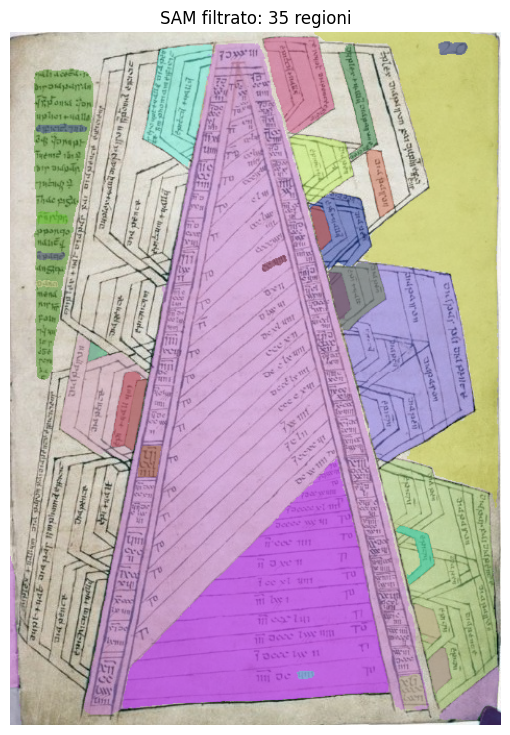

In [ ]:

def mask_iou(m1, m2):
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return inter / union if union > 0 else 0.0


def filter_masks(masks, image_area, max_area_ratio=0.6, iou_dedup_thresh=0.85):
    # 1) scarta maschere troppo grandi (probabile sfondo/pagina intera)
    filtered = [m for m in masks if m["area"] / image_area <= max_area_ratio]

    # 2) deduplica per overlap forte, tenendo la più piccola (più specifica)
    filtered = sorted(filtered, key=lambda m: m["area"])
    kept = []
    for m in filtered:
        seg = m["segmentation"]
        if any(mask_iou(seg, k["segmentation"]) > iou_dedup_thresh for k in kept):
            continue
        kept.append(m)
    return kept


clean_masks = filter_masks(masks, image_area=W * H)
print(f"Regioni dopo il filtro: {len(clean_masks)} (da {len(masks)})")

preview_clean = show_masks_overlay(image_rgb, clean_masks)
plt.figure(figsize=(9, 9))
plt.imshow(preview_clean)
plt.title(f"SAM filtrato: {len(clean_masks)} regioni")
plt.axis("off")
plt.show()


In [ ]:
# Seleziona la sorgente di regioni da usare nel resto della pipeline
if CONFIG["region_method"] == "polygonize":
    clean_masks = clean_masks_polygonize
elif CONFIG["region_method"] == "floodfill":
    clean_masks = clean_masks_floodfill
elif CONFIG["region_method"] == "sam":
    pass  # 'clean_masks' è già impostato dalle celle SAM (Step 4) sopra
else:
    raise ValueError(f"region_method sconosciuto: {CONFIG['region_method']}")

print(f"Metodo di segmentazione regioni attivo: {CONFIG['region_method']} -> {len(clean_masks)} regioni")


Metodo di segmentazione regioni attivo: polygonize -> 67 regioni


In [ ]:
# Applica il filtro testo/forma alle regioni SAM appena pulite (Step 3.5)
clean_masks, text_masks, ambiguous_masks = split_regions_by_text(
    clean_masks, text_mask,
    CONFIG["text_detection"]["overlap_thresh_regions"],
    CONFIG["text_detection"]["ambiguous_band"],
)
print(f"Regioni -> forma: {len(clean_masks)} | testo: {len(text_masks)} | ambigue: {len(ambiguous_masks)}")


Regioni -> forma: 48 | testo: 1 | ambigue: 18


## 6. Step 5 — Da maschere a poligoni SVG

Convertiamo ogni maschera binaria in uno (o più, se ha buchi/isole) poligono
tramite `cv2.findContours`, poi semplifichiamo con Douglas-Peucker
(`cv2.approxPolyDP` o `shapely.simplify`) per non appesantire l'SVG con migliaia
di vertici pixel-perfect: su un diagramma disegnato a mano non serve, e rende
il file più leggero da rifinire (a mano o, in futuro, via LLM).

In [ ]:

def mask_to_svg_paths(mask, simplify_tol=1.5):

    mask_u8 = (mask.astype(np.uint8)) * 255
    contours, hierarchy = cv2.findContours(mask_u8, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    d_parts = []
    for c in contours:
        if cv2.contourArea(c) < 4:
            continue
        c = cv2.approxPolyDP(c, simplify_tol, True)
        if len(c) < 3:
            continue
        pts = c.reshape(-1, 2)
        d = "M " + " L ".join(f"{x},{y}" for x, y in pts) + " Z"
        d_parts.append(d)

    if not d_parts:
        return None
    return " ".join(d_parts)   # path unico, con evenodd gestisce automaticamente i buchi


region_paths = []
for m in clean_masks:
    d = mask_to_svg_paths(m["segmentation"])
    if d:
        region_paths.append({"d": d, "area": m["area"]})

print(f"Poligoni SVG generati: {len(region_paths)}")


Poligoni SVG generati: 48


In [ ]:

def polygon_to_svg_path(poly, simplify_tol: float = 1.0):
    poly = poly.simplify(simplify_tol, preserve_topology=True)
    rings = [poly.exterior] + list(poly.interiors)
    d_parts = []
    for ring in rings:
        coords = list(ring.coords)
        if len(coords) < 3:
            continue
        d = "M " + " L ".join(f"{x:.2f},{y:.2f}" for x, y in coords) + " Z"
        d_parts.append(d)
    return " ".join(d_parts) if d_parts else None


def region_to_svg_path(region, simplify_tol: float = 1.0):
    """Usa il poligono vettoriale esatto quando disponibile (metodo
    'polygonize'), altrimenti ricade sull'estrazione contorni via raster
    (metodi 'floodfill'/'sam', che espongono solo 'segmentation')."""
    if region.get("polygon") is not None:
        return polygon_to_svg_path(region["polygon"], simplify_tol)
    return mask_to_svg_paths(region["segmentation"], simplify_tol)


## 7. Step 6 — Merge in un unico SVG ibrido

Struttura del file finale:

```
<svg>
  <g id="regions">   <!-- fill delle aree, sotto -->
  <g id="lines">      <!-- stroke di DSV, sopra -->
</svg>
```

Le regioni sono renderizzate per prime (sotto), le linee sopra, così i tratti
di DSV restano sempre visibili e definiscono i bordi percepiti; il fill delle
aree è pensato come layer semantico/colorabile (può restare grigio neutro o
essere ricolorato in un secondo momento, es. per codificare tipi di elemento).

In [ ]:

def build_hybrid_svg(region_paths, line_items_shape, line_items_text, width, height, out_path,
                      region_fill="#cfcfcf", region_opacity=0.5,
                      text_stroke="#cc0000", text_fill="#cc0000"):
    dwg = svgwrite.Drawing(out_path, size=(width, height), viewBox=f"0 0 {width} {height}")

    # --- layer regioni "forma" (sotto) ---
    g_regions = dwg.g(id="regions")
    for i, rp in enumerate(region_paths):
        g_regions.add(dwg.path(
            d=rp["d"], fill=region_fill, fill_opacity=region_opacity,
            fill_rule="evenodd", stroke="none", id=f"region_{i}",
        ))
    dwg.add(g_regions)

    # --- layer linee "forma" (sopra) ---
    g_lines = dwg.g(id="lines")
    for i, item in enumerate(line_items_shape):
        p, attr = item["path"], item["attr"]
        style = {k: v for k, v in attr.items() if k in ("stroke", "stroke-width", "opacity")}
        style.setdefault("stroke", "black")
        style.setdefault("stroke-width", 1)
        g_lines.add(dwg.path(d=p.d(), fill="none", id=f"line_{i}", **style))
    dwg.add(g_lines)

    # --- layer testo, NON cancellato: presente ma nascosto e riattivabile ---
    g_text = dwg.g(id="text_candidates", display="none")
    for i, item in enumerate(line_items_text):
        p = item["path"]
        g_text.add(dwg.path(d=p.d(), fill="none", stroke=text_stroke,
                             stroke_width=1, id=f"text_line_{i}"))
    dwg.add(g_text)

    dwg.save()
    return out_path


region_paths = []
for m in clean_masks:
    d = region_to_svg_path(m)
    if d:
        region_paths.append({"d": d, "area": m["area"]})

hybrid_svg_path = os.path.join(CONFIG["out_dir"], "hybrid_diagram.svg")
build_hybrid_svg(region_paths, lines_shape, lines_text, W, H, hybrid_svg_path)
print("SVG ibrido salvato in:", hybrid_svg_path)
print(f"Layer 'text_candidates' presente ma nascosto: {len(lines_text)} linee spostate lì "
      f"(riattivabile impostando display:inline sul gruppo #text_candidates).")


SVG ibrido salvato in: outputs/hybrid_diagram.svg
Layer 'text_candidates' presente ma nascosto: 236 linee spostate lì (riattivabile impostando display:inline sul gruppo #text_candidates).


## 7.1 — Incorporare le trascrizioni nell'SVG ibrido

Aggiungo un layer nascosto `<g id="text_transcriptions">` con un elemento
`<text>` per ogni riga trascritta, posizionato esattamente alle coordinate
pixel della riga (stesso sistema di riferimento di tutto l'SVG, già allineato
nello Step 2.1). Ogni `<text>` porta anche `data-bbox` e `data-confidence`
come attributi, per poterlo interrogare via XML/JS senza dover riparsare il
JSON a parte.

In [ ]:

def add_transcription_layer(svg_path: str, transcriptions: list, out_path: str,
                             font_size: int = 12, color: str = "#0000cc"):
    import xml.etree.ElementTree as ET
    ET.register_namespace("", "http://www.w3.org/2000/svg")
    tree = ET.parse(svg_path)
    root = tree.getroot()
    ns = "{http://www.w3.org/2000/svg}"

    g = ET.SubElement(root, f"{ns}g", {"id": "text_transcriptions", "display": "none"})
    for t in transcriptions:
        b = t.get("bbox_px")
        if not b or not t.get("text"):
            continue
        el = ET.SubElement(g, f"{ns}text", {
            "id": t["id"],
            "x": str(b["x"]),
            "y": str(b["y"] + b["h"]),  # baseline ~ bordo inferiore del bbox
            "font-size": str(font_size),
            "fill": color,
            "data-bbox": f'{b["x"]},{b["y"]},{b["w"]},{b["h"]}',
            "data-confidence": str(t.get("confidence")),
        })
        el.text = t["text"]

    tree.write(out_path, encoding="unicode", xml_declaration=False)
    return out_path


hybrid_annotated_path = os.path.join(CONFIG["out_dir"], "hybrid_diagram_annotated.svg")
add_transcription_layer(hybrid_svg_path, transcriptions, hybrid_annotated_path)
print("SVG ibrido annotato con le trascrizioni salvato in:", hybrid_annotated_path)
print("Layer 'text_transcriptions' nascosto per default (display:none sul gruppo).")


SVG ibrido annotato con le trascrizioni salvato in: outputs/hybrid_diagram_annotated.svg
Layer 'text_transcriptions' nascosto per default (display:none sul gruppo).


## 8. Confronto visivo: originale vs solo-linee vs ibrido

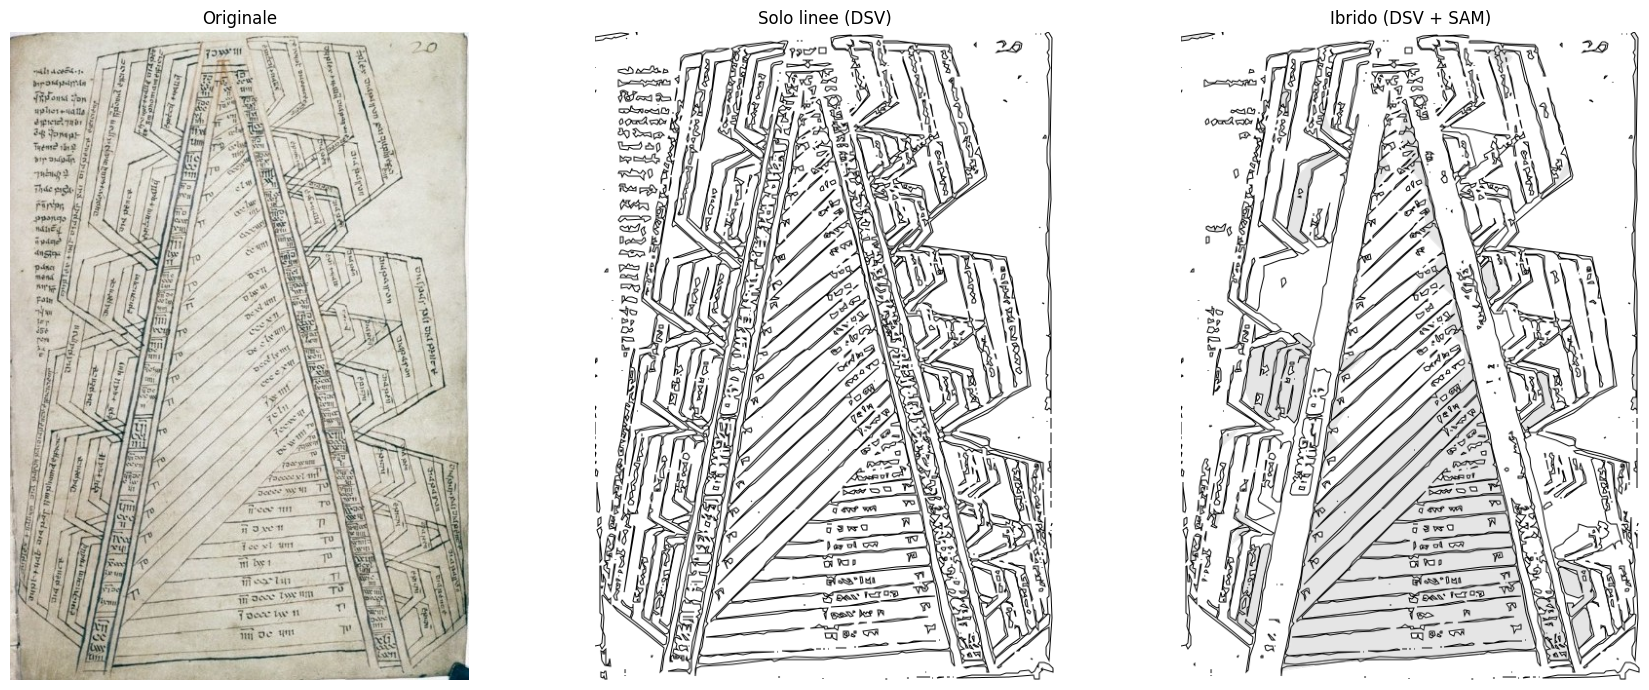

In [ ]:

import cairosvg
import io

def render_svg_to_array(svg_path, width, height):
    png_bytes = cairosvg.svg2png(url=svg_path, output_width=width, output_height=height)
    img = Image.open(io.BytesIO(png_bytes)).convert("RGBA")
    return np.array(img)

lines_render = render_svg_to_array(lines_svg_path, W, H)
hybrid_render = render_svg_to_array(hybrid_svg_path, W, H)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
axes[0].imshow(image_rgb); axes[0].set_title("Originale"); axes[0].axis("off")
axes[1].imshow(lines_render); axes[1].set_title("Solo linee (DSV)"); axes[1].axis("off")
axes[2].imshow(hybrid_render); axes[2].set_title("Ibrido (DSV + SAM)"); axes[2].axis("off")
plt.tight_layout()
plt.show()


## 9. (Stub) Step 7 — Rifinitura via LLM

Placeholder deliberatamente non implementato in questa fase. L'idea per il
prossimo step:

1. renderizzare `hybrid_svg_path` a PNG (`cairosvg`, già disponibile qui sopra);
2. inviare a un LLM multimodale sia il PNG renderizzato sia l'immagine
   originale, chiedendo un confronto strutturato (linee mancanti, regioni
   fuse/erronee, geometrie da correggere);
3. tradurre il feedback testuale/strutturato in **operazioni sull'SVG**
   (aggiungere/rimuovere path, spostare vertici, unire regioni) invece di
   rigenerare l'immagine da zero, per restare "vector-native";
4. iterare con un numero limitato di round e un criterio di stop (es. diff
   percettivo sotto soglia, o numero massimo di iterazioni).

```python
def refine_svg_with_llm(svg_path, reference_image_path, max_rounds=3):
    raise NotImplementedError("Step successivo della pipeline.")
```


In [ ]:
def refine_svg_with_llm(svg_path, reference_image_path, ambiguous_lines=None,
                         ambiguous_masks=None, max_rounds=3):
    """Placeholder per lo step futuro di rifinitura via LLM multimodale.

    Oltre al confronto generale SVG-vs-immagine descritto sopra, questo stub
    riceve anche gli elementi "ambigui" prodotti dallo Step 3.5 (linee e
    regioni la cui sovrapposizione con le zone di testo è nella banda
    incerta): per ciascuno, il piano è ritagliare un piccolo crop
    dell'immagine originale attorno a quell'elemento e chiedere all'LLM un
    giudizio binario "testo / forma del diagramma" — un compito molto più
    affidabile per un LLM multimodale rispetto alla localizzazione fine su
    tutto l'SVG.

    Non ancora implementato: vedi discussione nella cella markdown sopra.
    """
    raise NotImplementedError("Step successivo della pipeline.")
